Loading candidate sites...
  Sites loaded: 200
  Columns: ['score', 'lon', 'lat', 'grid_lon', 'grid_lat', 'site_id', 'province', 'region', 'geometry']

Extracting feature values at candidate sites...
  ✅ dist_pop: min=1.28 max=13.55
  ✅ dist_port: min=1.74 max=107.91
  ✅ dist_road: min=0.04 max=11.83
  ✅ dist_river: min=0.15 max=12.26
  ✅ pop_density: min=0.00 max=73.54
  ✅ slope: min=0.00 max=81.95

Computing demand per site...
  demand_mwe: min=0.000 max=7.121 mean=1.054

Running elbow + silhouette analysis...
  k=2: inertia=910.4 | silhouette=0.519
  k=3: inertia=672.7 | silhouette=0.408
  k=4: inertia=540.5 | silhouette=0.390
  k=5: inertia=383.5 | silhouette=0.410
  k=6: inertia=308.7 | silhouette=0.372
  k=7: inertia=271.3 | silhouette=0.387


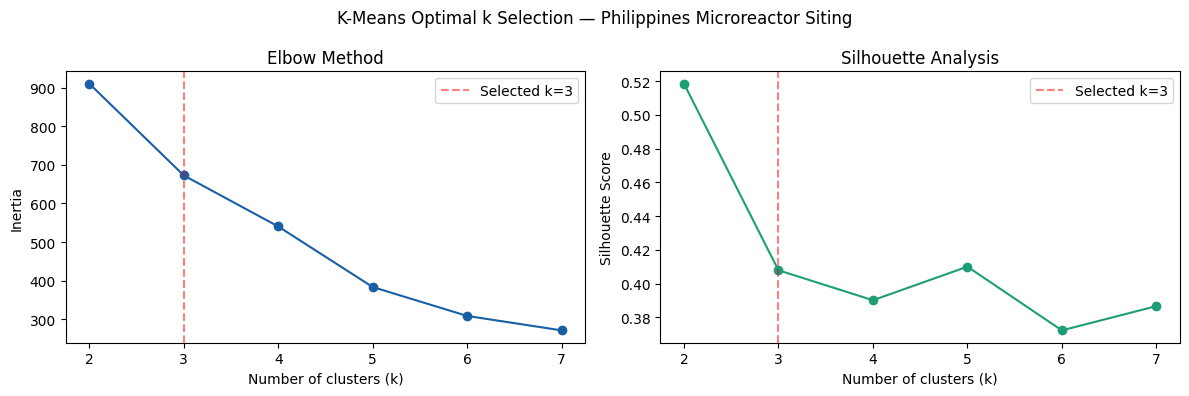

✅ Saved: kmeans_optimization.png

Fitting final K-Means with k=3...
(k=3 selected for deployment interpretability — three distinct
 archipelagic deployment tiers; silhouette=0.408 acceptable)

Cluster distribution:
  Cluster 0: 144 sites
  Cluster 1: 20 sites
  Cluster 2: 36 sites

Cluster profiles (mean values):
         dist_pop  dist_port  dist_road  dist_river  pop_density  demand_mwe      score
cluster                                                                                
0            2.63  17.450001       0.51        0.60         7.46        0.70  89.029999
1            7.66   7.130000       2.93        3.50         2.05        0.13  77.089996
2            2.75  11.050000       0.83        0.61        31.09        2.98  91.419998

Assigning archetype names...
  Cluster 0: dist_pop=2.6km | dist_port=17.5km | demand=0.70MWe
  Cluster 1: dist_pop=7.7km | dist_port=7.1km | demand=0.13MWe
  Cluster 2: dist_pop=2.8km | dist_port=11.1km | demand=2.98MWe

Archetype assignments:


In [2]:
# ═══════════════════════════════════════════════════════════
# Notebook 06 — K-Means Clustering + Deployment Archetypes
# Microreactor Siting — Philippines
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import os

PROCESSED = r"C:\Users\ailene.nunez\Downloads\microreactor_siting\data\processed"
FIGURES   = r"C:\Users\ailene.nunez\Downloads\microreactor_siting\figures"
RAW       = r"C:\Users\ailene.nunez\Downloads\microreactor_siting\data\raw"
os.makedirs(FIGURES, exist_ok=True)

# ═══════════════════════════════════════════════════════════
# SECTION 1 — Load top 200 candidate sites
# ═══════════════════════════════════════════════════════════

print("Loading candidate sites...")
sites = gpd.read_file(f"{PROCESSED}/top_200_candidates.gpkg")
print(f"  Sites loaded: {len(sites)}")
print(f"  Columns: {sites.columns.tolist()}")

# ═══════════════════════════════════════════════════════════
# SECTION 2 — Extract feature values at each site
# ═══════════════════════════════════════════════════════════

print("\nExtracting feature values at candidate sites...")

TARGET_H, TARGET_W = 2000, 1600

def sample_raster_at_points(raster_path, lons, lats):
    with rasterio.open(raster_path) as src:
        data = src.read(
            1,
            out_shape=(TARGET_H, TARGET_W),
            resampling=Resampling.bilinear
        ).astype(np.float32)
        bounds = src.bounds
    col_idx = ((lons - bounds.left)  / (bounds.right - bounds.left)  * TARGET_W).astype(int)
    row_idx = ((bounds.top - lats)   / (bounds.top   - bounds.bottom) * TARGET_H).astype(int)
    col_idx = np.clip(col_idx, 0, TARGET_W - 1)
    row_idx = np.clip(row_idx, 0, TARGET_H - 1)
    return data[row_idx, col_idx]

lons = sites["lon"].values
lats = sites["lat"].values

# Load slope from DEM
with rasterio.open(f"{PROCESSED}/dem_4326.tif") as src:
    dem_data = src.read(
        1,
        out_shape=(TARGET_H, TARGET_W),
        resampling=Resampling.bilinear
    ).astype(np.float64)
dy, dx = np.gradient(dem_data, 1000, 1000)
slope_grid = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2))).astype(np.float32)
del dem_data, dx, dy

def sample_array_at_points(arr, bounds, lons, lats):
    col_idx = ((lons - bounds.left)  / (bounds.right - bounds.left)  * TARGET_W).astype(int)
    row_idx = ((bounds.top - lats)   / (bounds.top   - bounds.bottom) * TARGET_H).astype(int)
    col_idx = np.clip(col_idx, 0, TARGET_W - 1)
    row_idx = np.clip(row_idx, 0, TARGET_H - 1)
    return arr[row_idx, col_idx]

with rasterio.open(f"{PROCESSED}/dem_4326.tif") as src:
    dem_bounds = src.bounds

raster_features = {
    "dist_pop":    f"{PROCESSED}/dist_pop.tif",
    "dist_port":   f"{PROCESSED}/dist_port.tif",
    "dist_road":   f"{PROCESSED}/dist_road.tif",
    "dist_river":  f"{PROCESSED}/dist_river.tif",
    "pop_density": f"{PROCESSED}/population_density.tif",
}

for feat, path in raster_features.items():
    sites[feat] = sample_raster_at_points(path, lons, lats)
    print(f"  ✅ {feat}: min={sites[feat].min():.2f} max={sites[feat].max():.2f}")

sites["slope"] = sample_array_at_points(slope_grid, dem_bounds, lons, lats)
print(f"  ✅ slope: min={sites['slope'].min():.2f} max={sites['slope'].max():.2f}")

# ═══════════════════════════════════════════════════════════
# SECTION 3 — Compute demand_mwe per site
# ═══════════════════════════════════════════════════════════

print("\nComputing demand per site...")

SERVICE_AREA_KM2 = np.pi * 15**2

def assign_consumption(dist_pop):
    if dist_pop < 5:
        return 1200
    elif dist_pop < 20:
        return 800
    else:
        return 500

sites["kwh_per_capita"] = sites["dist_pop"].apply(assign_consumption)
sites["pop_served"]     = sites["pop_density"] * SERVICE_AREA_KM2
sites["annual_kwh"]     = sites["pop_served"] * sites["kwh_per_capita"]
sites["demand_mwe"]     = sites["annual_kwh"] / 8760 / 1000

print(f"  demand_mwe: min={sites['demand_mwe'].min():.3f} "
      f"max={sites['demand_mwe'].max():.3f} "
      f"mean={sites['demand_mwe'].mean():.3f}")

# ═══════════════════════════════════════════════════════════
# SECTION 4 — K-Means elbow + silhouette (for documentation)
# ═══════════════════════════════════════════════════════════

print("\nRunning elbow + silhouette analysis...")

cluster_features = [
    "dist_pop", "dist_port", "dist_road",
    "dist_river", "pop_density", "demand_mwe"
]

X_cluster = sites[cluster_features].values
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

inertias   = []
sil_scores = []
k_range    = range(2, 8)

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    print(f"  k={k}: inertia={km.inertia_:.1f} | silhouette={sil_scores[-1]:.3f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertias, marker="o", color="#185FA5")
ax1.axvline(x=3, color="red", linestyle="--", alpha=0.5, label="Selected k=3")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.legend()

ax2.plot(list(k_range), sil_scores, marker="o", color="#1D9E75")
ax2.axvline(x=3, color="red", linestyle="--", alpha=0.5, label="Selected k=3")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Analysis")
ax2.legend()

plt.suptitle("K-Means Optimal k Selection — Philippines Microreactor Siting", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIGURES}/kmeans_optimization.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Saved: kmeans_optimization.png")

# ═══════════════════════════════════════════════════════════
# SECTION 5 — Final K-Means with k=3
# ═══════════════════════════════════════════════════════════

print("\nFitting final K-Means with k=3...")
print("(k=3 selected for deployment interpretability — three distinct")
print(" archipelagic deployment tiers; silhouette=0.408 acceptable)")

km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
sites["cluster"] = km_final.fit_predict(X_scaled)

print("\nCluster distribution:")
for c in range(3):
    n = (sites["cluster"] == c).sum()
    print(f"  Cluster {c}: {n} sites")

# ── Cluster profiles ───────────────────────────────────────
profile_cols = cluster_features + ["score"]
profiles     = sites.groupby("cluster")[profile_cols].mean().round(2)
print("\nCluster profiles (mean values):")
print(profiles.to_string())

# ═══════════════════════════════════════════════════════════
# SECTION 6 — Archetype naming from profiles
# ═══════════════════════════════════════════════════════════

print("\nAssigning archetype names...")
archetype_map = {}

for c in range(3):
    dp  = profiles.loc[c, "dist_pop"]
    dpt = profiles.loc[c, "dist_port"]
    dem = profiles.loc[c, "demand_mwe"]
    print(f"  Cluster {c}: dist_pop={dp:.1f}km | dist_port={dpt:.1f}km | demand={dem:.2f}MWe")

    if dp < 5 and dem > 0.8:
        archetype_map[c] = "Peri-Urban Grid Anchor"
    elif dpt < 20 and dem <= 0.8:
        archetype_map[c] = "Coastal Island Hub"
    else:
        archetype_map[c] = "Remote Archipelago Endpoint"

sites["archetype"] = sites["cluster"].map(archetype_map)

print("\nArchetype assignments:")
for c, name in archetype_map.items():
    n = (sites["cluster"] == c).sum()
    print(f"  Cluster {c}: {name} ({n} sites)")

# ═══════════════════════════════════════════════════════════
# SECTION 7 — Reactor sizing from demand
# ═══════════════════════════════════════════════════════════

print("\nAssigning reactor sizes...")

def assign_reactor(demand_mwe):
    sized = demand_mwe * 1.2
    if sized <= 1.5:   return 1
    elif sized <= 3.5: return 2
    elif sized <= 7.5: return 5
    elif sized <= 15:  return 10
    else:              return 20

sites["reactor_mwe"] = sites["demand_mwe"].apply(assign_reactor)

print("Reactor size distribution:")
print(sites["reactor_mwe"].value_counts().sort_index().to_string())

print("\nReactor sizes by archetype:")
print(sites.groupby("archetype")["reactor_mwe"].value_counts().to_string())

# ═══════════════════════════════════════════════════════════
# SECTION 8 — Energy Coverage Ratio
# ═══════════════════════════════════════════════════════════

print("\nCalculating Energy Coverage Ratio...")

def ecr_category(ecr):
    if ecr > 1.5:    return "Oversupply"
    elif ecr >= 1.0: return "Balanced"
    elif ecr >= 0.7: return "Adequate"
    else:            return "Undersupply"

sites["ECR"]          = sites["reactor_mwe"] / sites["demand_mwe"].replace(0, np.nan)
sites["ecr_category"] = sites["ECR"].apply(ecr_category)

print(f"ECR statistics:")
print(f"  Min:  {sites['ECR'].min():.2f}")
print(f"  Max:  {sites['ECR'].max():.2f}")
print(f"  Mean: {sites['ECR'].mean():.2f}")
print(f"\nECR categories:")
print(sites["ecr_category"].value_counts().to_string())

# ═══════════════════════════════════════════════════════════
# SECTION 9 — Final composite ranking
# ═══════════════════════════════════════════════════════════

print("\nComputing final composite ranking...")

sites["suit_norm"]   = sites["score"] / 100
sites["ecr_norm"]    = (1 - np.abs(sites["ECR"] - 1.2) / 1.2).clip(0, 1)
sites["final_score"] = 0.6 * sites["suit_norm"] + 0.4 * sites["ecr_norm"]
sites = sites.sort_values("final_score", ascending=False).reset_index(drop=True)
sites["final_rank"]  = range(1, len(sites) + 1)

print("\nTop 20 ranked sites:")
cols = ["final_rank", "site_id", "lat", "lon",
        "score", "archetype", "reactor_mwe",
        "demand_mwe", "ECR", "ecr_category"]
if "province" in sites.columns:
    cols.insert(4, "province")
if "region" in sites.columns:
    cols.insert(5, "region")

print(sites[cols].head(20).to_string())

# ═══════════════════════════════════════════════════════════
# SECTION 10 — Save outputs
# ═══════════════════════════════════════════════════════════

sites.to_file(f"{PROCESSED}/sites_clustered_ranked.gpkg", driver="GPKG")

save_cols = ["final_rank", "site_id", "lat", "lon",
             "score", "archetype", "cluster",
             "reactor_mwe", "demand_mwe", "ECR", "ecr_category"]
if "province" in sites.columns:
    save_cols.insert(4, "province")
if "region" in sites.columns:
    save_cols.insert(5, "region")

sites[save_cols].to_csv(f"{PROCESSED}/top_20_sites.csv", index=False)

print("\n✅ sites_clustered_ranked.gpkg saved")
print("✅ top_20_sites.csv saved")
print(f"\nPhase 6 complete — {len(sites)} sites clustered and ranked")